In [1]:
# Set up the proper working directory

import os

current_dir = os.getcwd()
if current_dir.split('/')[-1] == 'notebooks':
    os.chdir('..')

print("Current working directory:", os.getcwd())

Current working directory: /mnt/e/Google Drive/Scolaire/Mines/ue53-NLP/projet/arrayxtract


In [2]:
from scripts.data_preprocessing import preprocess_PDF2Images, convert_raw_annotations
from scripts.dataset import getPositiveImages, ArreysDetectDataset
from scripts.visualize import show_sample, show_sample_from_dataset

import numpy as np
import os
import matplotlib.pyplot as plt
import json

from torch import Generator
from torch.utils.data import DataLoader, random_split

%load_ext autoreload
%autoreload 2

In [3]:
root = 'data/'

filenames = getPositiveImages(root)

rng = np.random.default_rng(seed=42)
rng.shuffle(filenames)

In [4]:
n_train, n_val = int(0.8 * len(filenames)), int(0.1 * len(filenames))
n_test = len(filenames) - n_train - n_val

train_set = ArreysDetectDataset(root, filenames[:n_train])
val_set = ArreysDetectDataset(root, filenames[n_train:n_train+n_val], train=False)
test_set = ArreysDetectDataset(root, filenames[n_train+n_val:], train=False)

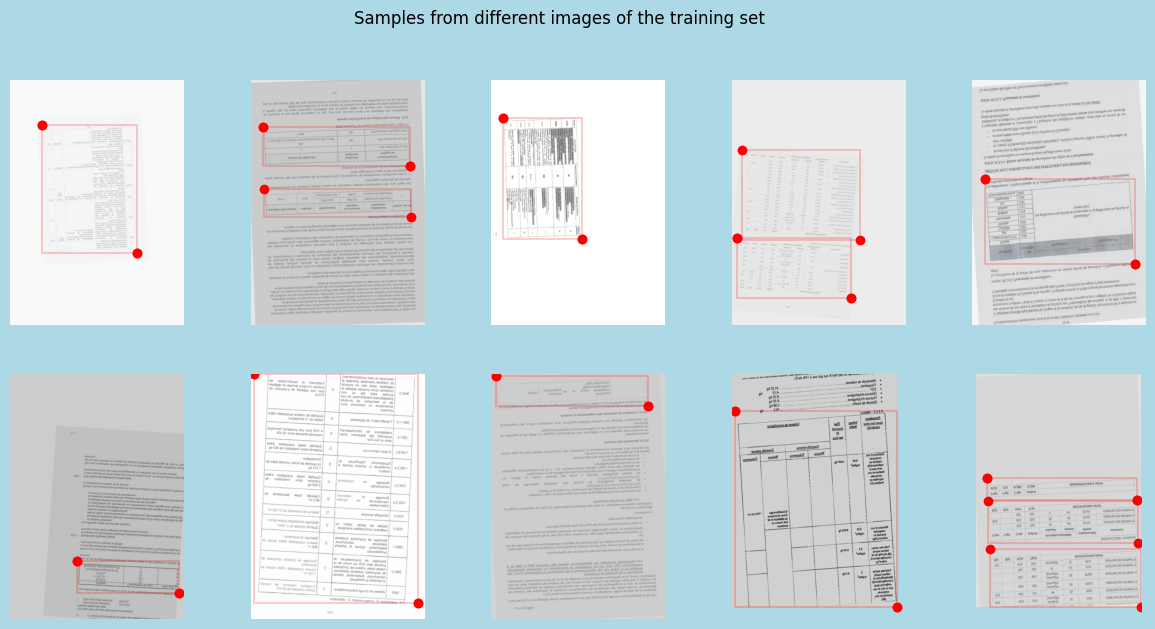

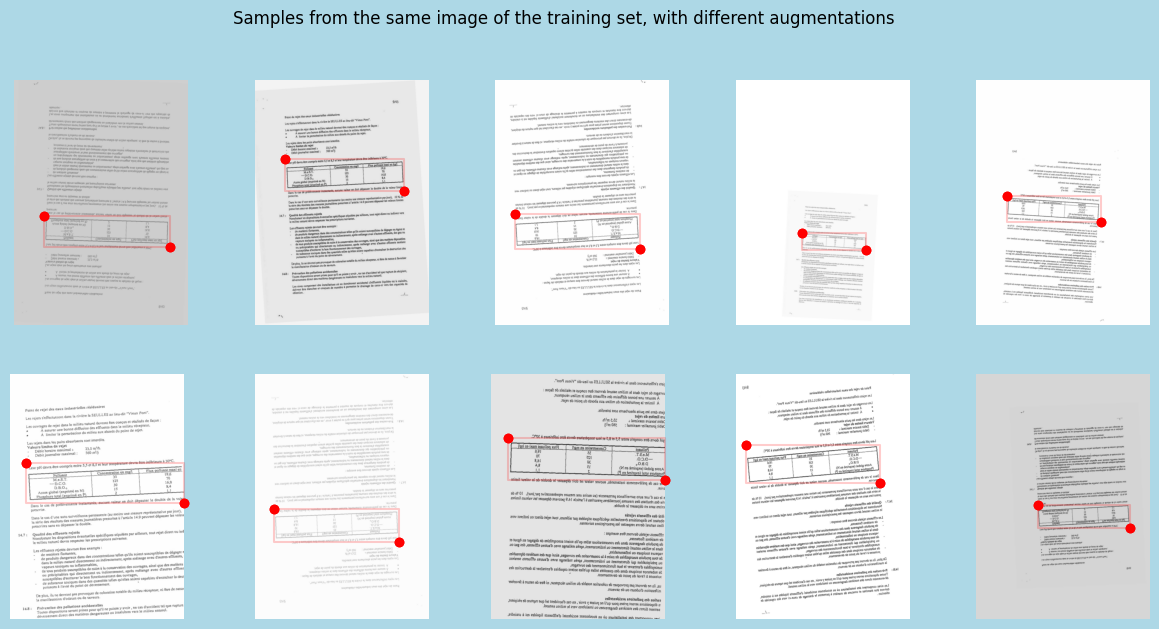

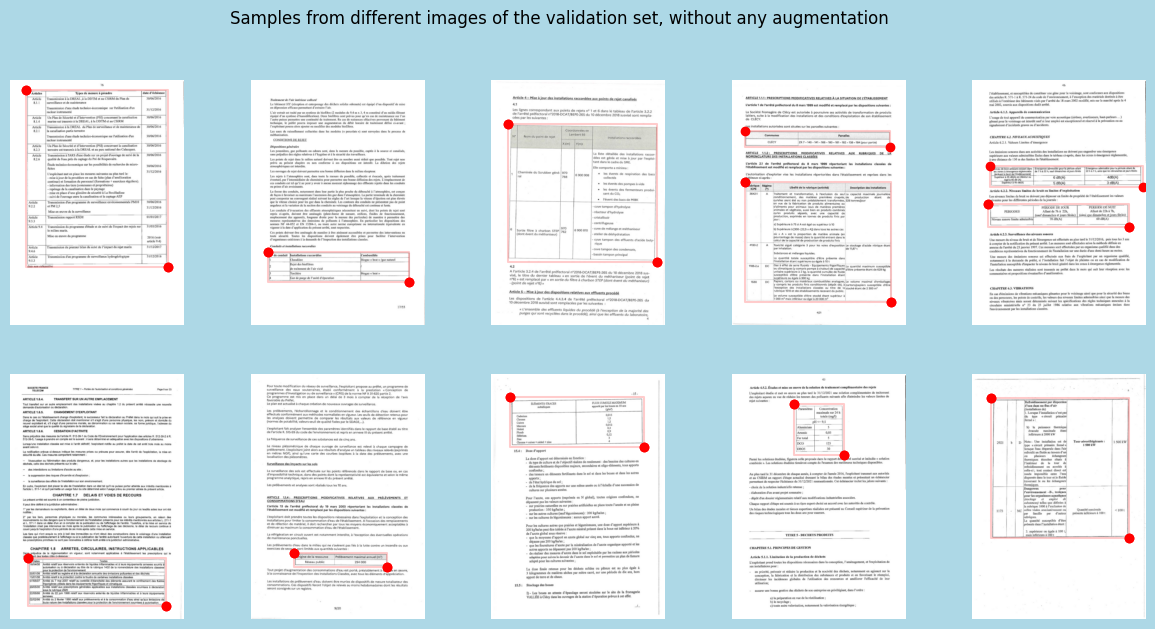

In [6]:
fig, axs = plt.subplots(2, 5, figsize=(15, 7))
for i in range(10) :
    show_sample_from_dataset(train_set, i, axs[i//5, i%5])
    fig.suptitle('Samples from different images of the training set')
    fig.patch.set_facecolor('lightblue')

fig, axs = plt.subplots(2, 5, figsize=(15, 7))
for i in range(10) :
    show_sample_from_dataset(train_set, 5, axs[i//5, i%5])
    fig.suptitle('Samples from the same image of the training set, with different augmentations')
    fig.patch.set_facecolor('lightblue')

fig, axs = plt.subplots(2, 5, figsize=(15, 7))
for i in range(10) :
    show_sample_from_dataset(val_set, i, axs[i//5, i%5])
    fig.suptitle('Samples from different images of the validation set, without any augmentation')
    fig.patch.set_facecolor('lightblue')